In [1]:

import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from utils.utils import convert_to_color, read_config, convert_to_artificiel, convert_to_vegetal, read_samples_df
 

In [2]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
config = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir)

Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/toy'),
 'files_csv': PosixPath('/workspaces/flairimages/data/toy/toydataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/toy/toydataset.pkl'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs'),
 'src': PosixPath('/workspaces/flairimages/src')}


In [3]:
config['nomenclature']['class_to_color'] 


{1: array([219,  14, 154], dtype=uint8),
 2: array([147, 142, 123], dtype=uint8),
 3: array([248,  12,   0], dtype=uint8),
 4: array([169, 113,   1], dtype=uint8),
 5: array([ 21,  83, 174], dtype=uint8),
 6: array([25, 74, 38], dtype=uint8),
 7: array([ 70, 228, 131], dtype=uint8),
 8: array([243, 166,  13], dtype=uint8),
 9: array([102,   0, 130], dtype=uint8),
 10: array([ 85, 255,   0], dtype=uint8),
 11: array([255, 243,  13], dtype=uint8),
 12: array([228, 223, 124], dtype=uint8),
 13: array([ 61, 230, 235], dtype=uint8),
 14: array([255, 255, 255], dtype=uint8),
 15: array([138, 179, 160], dtype=uint8),
 16: array([107, 113,  79], dtype=uint8),
 17: array([197, 220,  66], dtype=uint8),
 18: array([153, 153, 255], dtype=uint8),
 19: array([0, 0, 0], dtype=uint8)}

In [4]:

# read the sample table in csv format
df = read_samples_df(conf=config)
df.reset_index(drop=False, inplace=True)
df.head()



,name,image,mask,domain,zone,patch_centroid_x,patch_centroid_y,patch_centroid_z,date,time,camera
0,IMG_062871,/workspaces/flairimages/data/toy/flair_1_toy_d...,/workspaces/flairimages/data/toy/flair_1_toy_d...,D012_2019,Z13_AA,671590.4,6368716.8,625.98999,2019-09-29,10h13,CAMERA#020
1,IMG_063104,/workspaces/flairimages/data/toy/flair_1_toy_d...,/workspaces/flairimages/data/toy/flair_1_toy_d...,D012_2019,Z15_NF,716953.6,6328166.4,808.919983,2019-08-14,11h00,UCE-M3-f100
2,IMG_063120,/workspaces/flairimages/data/toy/flair_1_toy_d...,/workspaces/flairimages/data/toy/flair_1_toy_d...,D012_2019,Z15_NF,716544.0,6327961.6,839.320007,2019-08-14,14h19,UCE-M3-f100
3,IMG_063366,/workspaces/flairimages/data/toy/flair_1_toy_d...,/workspaces/flairimages/data/toy/flair_1_toy_d...,D012_2019,Z20_FF,701798.4,6332364.8,540.940002,2019-08-14,15h17,UCE-M3-f100
4,IMG_061946,/workspaces/flairimages/data/toy/flair_1_toy_d...,/workspaces/flairimages/data/toy/flair_1_toy_d...,D012_2019,Z3_UU,665446.4,6361753.6,579.440002,2019-09-29,11h39,CAMERA#020


(512, 512, 5)
uint8
0 251


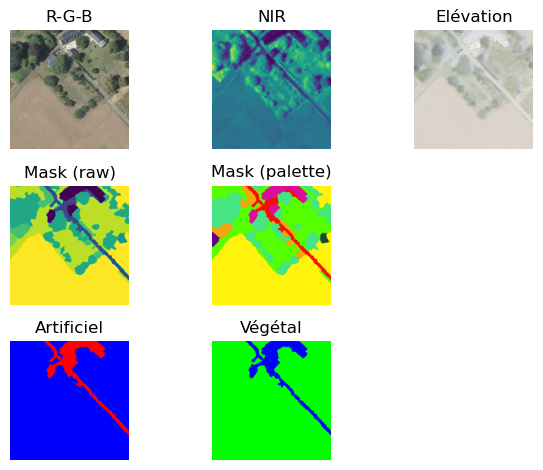

In [8]:
# select a random record from df
# and extract the name, image and mask file paths.
name, image_file, mask_file = df.sample().iloc[0][['name','image', 'mask']].values
# print(name)
# print(image_file)
# print(mask_file)
with rasterio.open(image_file) as src:
    img = src.read()
    img = np.moveaxis(img, 0, -1)
with rasterio.open(mask_file) as src:
    msk = src.read()
    
print(img.shape)
print(img.dtype)

print(img.min(), img.max())
#
plt.subplot(3,3,1)
plt.imshow(img[:,:,:3])
plt.title("R-G-B")
plt.axis("off")
#
plt.subplot(3,3,2)
plt.imshow(img[:,:,3:4])
plt.title("NIR")
plt.axis("off")
#
plt.subplot(3,3,3)
plt.imshow(img[:,:,:4])
plt.title("Elévation")
plt.axis("off")
#
plt.subplot(3,3,4)
plt.imshow(msk[0,:,:])
plt.title("Mask (raw)")
plt.axis("off")
#
msk_palette = convert_to_color(arr_2d=msk[0,:,:], config=config)
plt.subplot(3,3,5)
plt.imshow(msk_palette)
plt.title("Mask (palette)")
plt.axis("off")
#
msk_artificiel = convert_to_artificiel(arr_2d=msk[0,:,:], conf=config)
plt.subplot(3,3,7)
plt.imshow(msk_artificiel)
plt.title("Artificiel")
plt.axis("off")
#
msk_vegetal = convert_to_vegetal(arr_2d=msk[0,:,:], conf=config)
plt.subplot(3,3,8)
plt.imshow(msk_vegetal)
plt.title("Végétal")
plt.axis("off")
#
plt.tight_layout()
plt.show()

    
    
